# Content Monetization Modeler

A beginner-friendly regression project that predicts `ad_revenue_usd` from YouTube video data.

## 1. Import Libraries

We import the simple libraries needed for data work, charts, model training, and saving the final model.

In [4]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42
DATA_FILE = Path("youtube_monetization.csv")
BACKUP_FILE = Path("youtube_ad_revenue_dataset.csv")
MODEL_FOLDER = Path("models")
MODEL_FOLDER.mkdir(exist_ok=True)
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

This cell looks for the CSV file in the current folder. If the named file is not found, it tries the backup file or the first CSV it can find.

In [5]:
def find_dataset():
    """Find the dataset without hardcoding a full path."""
    if DATA_FILE.exists():
        return DATA_FILE
    if BACKUP_FILE.exists():
        return BACKUP_FILE
    csv_files = list(Path.cwd().glob("*.csv"))
    if csv_files:
        return csv_files[0]
    return None

dataset_path = find_dataset()
if dataset_path is None:
    print("No CSV file found. Creating a small sample dataset.")
    rng = np.random.default_rng(RANDOM_STATE)
    df = pd.DataFrame({
        "video_id": [f"vid_{i}" for i in range(1, 51)],
        "date": pd.date_range("2024-01-01", periods=50, freq="D"),
        "views": rng.integers(1000, 50000, 50),
        "likes": rng.integers(100, 5000, 50),
        "comments": rng.integers(10, 500, 50),
        "watch_time_minutes": rng.integers(500, 20000, 50),
        "video_length_minutes": rng.integers(3, 30, 50),
        "subscribers": rng.integers(1000, 500000, 50),
        "category": rng.choice(["Education", "Gaming", "Music"], 50),
        "device": rng.choice(["Mobile", "Desktop", "TV"], 50),
        "country": rng.choice(["India", "United States", "Canada"], 50),
        "ad_revenue_usd": rng.uniform(20, 2000, 50).round(2)
    })
else:
    df = pd.read_csv(dataset_path)
    print(f"Loaded dataset: {dataset_path}")

display(df.head())

Loaded dataset: youtube_ad_revenue_dataset.csv


,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


## 3. Dataset Overview

We check the shape, column names, data types, summary statistics, missing values, and duplicate rows.

In [7]:
print("Shape:", df.shape)
print("\nColumn names:")
print(list(df.columns))

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
df.info()

print("\nNumeric summary:")
display(df.describe())

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (122400, 12)

Column names:
['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'category', 'device', 'country', 'ad_revenue_usd']

First 5 rows:


,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388



Data types:
<class 'pandas.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  str    
 1   date                  122400 non-null  str    
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  str    
 9   device                122400 non-null  str    
 10  country               122400 non-null  str    
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), str(5)
memory usage: 16.9 MB

Numeric summary:


,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254



Missing values:


,missing_count
video_id,0
date,0
views,0
likes,6117
comments,6112
watch_time_minutes,6105
video_length_minutes,0
subscribers,0
category,0
device,0



Duplicate rows: 2400


## 4. Basic Data Cleaning

Now we clean the data by fixing column names, converting types, removing duplicates, and filling simple missing values.

In [15]:
df = df.copy()
df.columns = df.columns.str.lower().str.strip()

df["date"] = pd.to_datetime(df["date"], errors="coerce")

numeric_cols = ["views", "likes", "comments", "watch_time_minutes", "video_length_minutes", "subscribers", "ad_revenue_usd"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

cat_cols = ["video_id", "category", "device", "country"]
for col in cat_cols:
    df[col] = df[col].astype("string").str.strip()

df = df.drop_duplicates()
df = df.dropna(subset=["ad_revenue_usd"])

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in ["category", "device", "country", "video_id"]:
    df[col] = df[col].fillna("Unknown")

print("Cleaned shape:", df.shape)
display(df.isnull().sum().to_frame("missing_count"))

Cleaned shape: (120000, 14)


,missing_count
video_id,0
date,0
views,0
likes,0
comments,0
watch_time_minutes,0
video_length_minutes,0
subscribers,0
category,0
device,0


## 5. Simple Exploratory Data Analysis (EDA)

We make a few easy plots to understand the target value and how it relates to other columns.

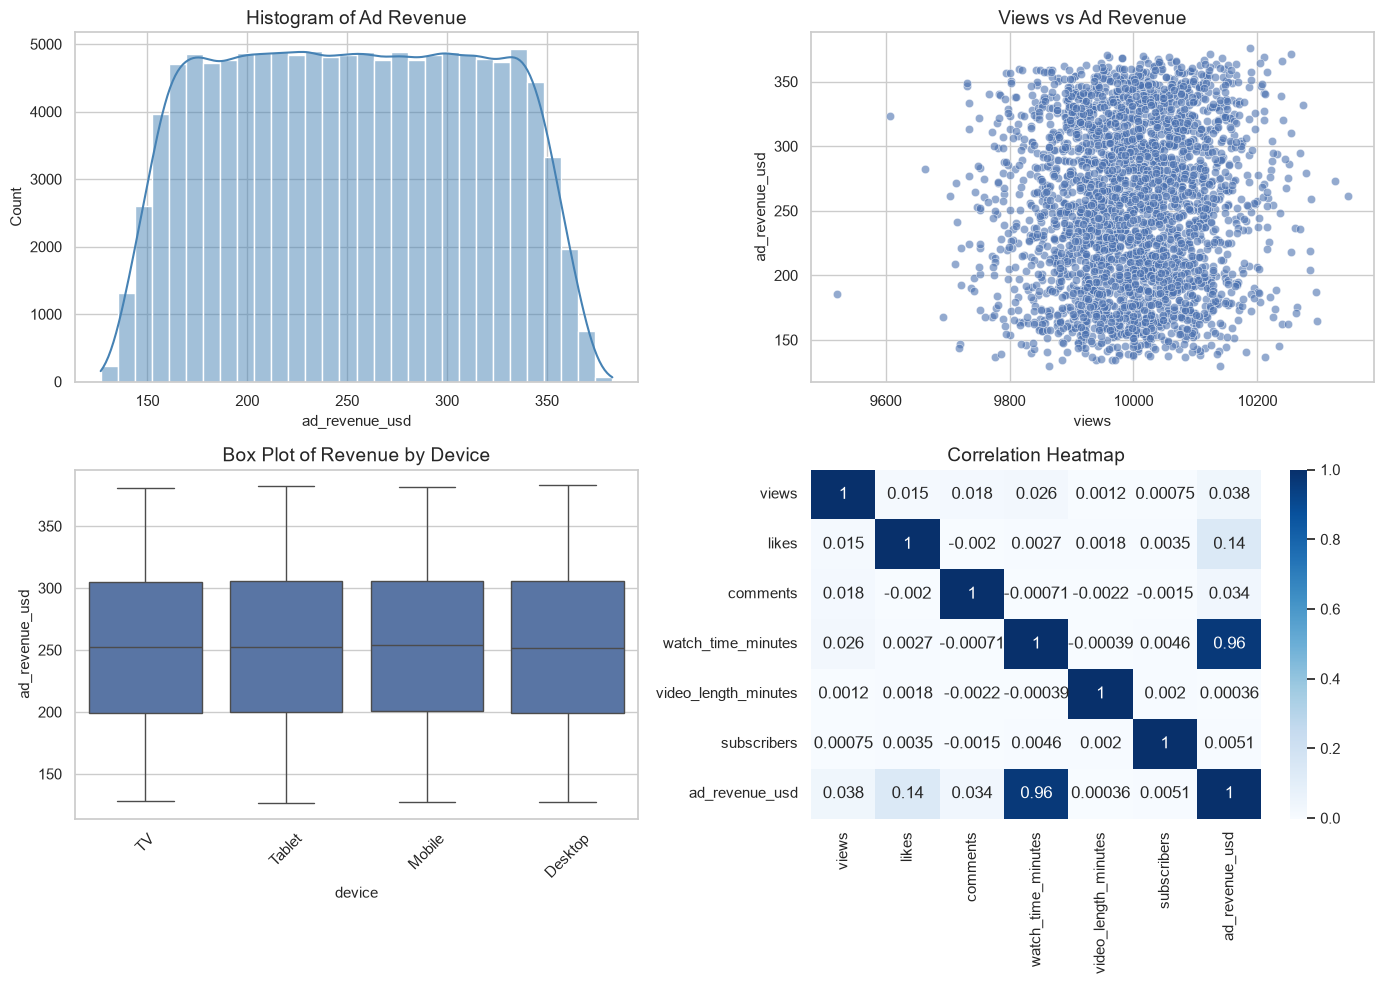

In [16]:
sample_df = df.sample(n=min(3000, len(df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["ad_revenue_usd"], bins=30, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Histogram of Ad Revenue")

sns.scatterplot(data=sample_df, x="views", y="ad_revenue_usd", ax=axes[0, 1], alpha=0.6)
axes[0, 1].set_title("Views vs Ad Revenue")

sns.boxplot(data=df, x="device", y="ad_revenue_usd", ax=axes[1, 0])
axes[1, 0].set_title("Box Plot of Revenue by Device")
axes[1, 0].tick_params(axis="x", rotation=45)

corr_cols = ["views", "likes", "comments", "watch_time_minutes", "video_length_minutes", "subscribers", "ad_revenue_usd"]
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="Blues", ax=axes[1, 1])
axes[1, 1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## 6. Feature Engineering

We create two simple new features that can help the model learn better from the raw data.

In [11]:
df["engagement_rate"] = (df["likes"] + df["comments"]) / (df["views"] + 1)
df["watch_ratio"] = df["watch_time_minutes"] / (df["video_length_minutes"] + 1)
print("New features added: engagement_rate and watch_ratio")
display(df[["engagement_rate", "watch_ratio"]].head())

New features added: engagement_rate and watch_ratio


,engagement_rate,watch_ratio
0,0.155077,6860.765669
1,0.098622,614.831646
2,0.214498,2107.769228
3,0.142800,2453.694859
4,0.236097,2051.593275


## 7. Encoding

The model needs numeric input, so we convert category columns into dummy columns with one-hot encoding.

In [12]:
df_model = df.drop(["video_id", "date"], axis=1)
df_encoded = pd.get_dummies(df_model, columns=["category", "device", "country"], drop_first=True)
print("Encoded shape:", df_encoded.shape)
display(df_encoded.head())

Encoded shape: (120000, 22)


,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,engagement_rate,watch_ratio,category_Entertainment,category_Gaming,category_Lifestyle,category_Music,category_Tech,device_Mobile,device_TV,device_Tablet,country_CA,country_DE,country_IN,country_UK,country_US
0,9936,1221.0,320.0,26497.214184,2.862137,228086,203.178237,0.155077,6860.765669,True,False,False,False,False,False,True,False,False,False,True,False,False
1,10017,642.0,346.0,15209.747445,23.738069,736015,140.880508,0.098622,614.831646,False,True,False,False,False,False,False,True,True,False,False,False,False
2,10097,1979.0,187.0,57332.658498,26.200634,240534,360.134008,0.214498,2107.769228,False,False,False,False,False,False,True,False,True,False,False,False,False
3,10034,1191.0,242.0,31334.517771,11.770340,434482,224.638261,0.142800,2453.694859,True,False,False,False,False,True,False,False,False,False,False,True,False
4,9889,1858.0,477.0,15665.666434,6.635854,42030,165.514388,0.236097,2051.593275,False,False,False,False,False,True,False,False,True,False,False,False,False


## 8. Train-Test Split

We split the data into training and testing sets so we can check how well the model works on unseen data.

In [13]:
X = df_encoded.drop("ad_revenue_usd", axis=1)
y = df_encoded["ad_revenue_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
 )

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 96000
Testing rows: 24000


## 9. Train Regression Models

We train five simple regression models and compare them on the same test data.

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=5000),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    trained_models[name] = model
    results.append({
        "Model": name,
        "R2 Score": r2_score(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "MAE": mean_absolute_error(y_test, predictions)
    })

results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False).reset_index(drop=True)
display(results_df)

,Model,R2 Score,RMSE,MAE
0,Lasso Regression,0.952579,13.479344,3.106244
1,Ridge Regression,0.952578,13.479536,3.109611
2,Linear Regression,0.952577,13.479575,3.103504
3,Decision Tree Regressor,0.950121,13.824276,4.215809
4,Random Forest Regressor,0.948887,13.994237,3.664041


## 10. Compare Models

We plot the scores so it is easy to see which model performs best.

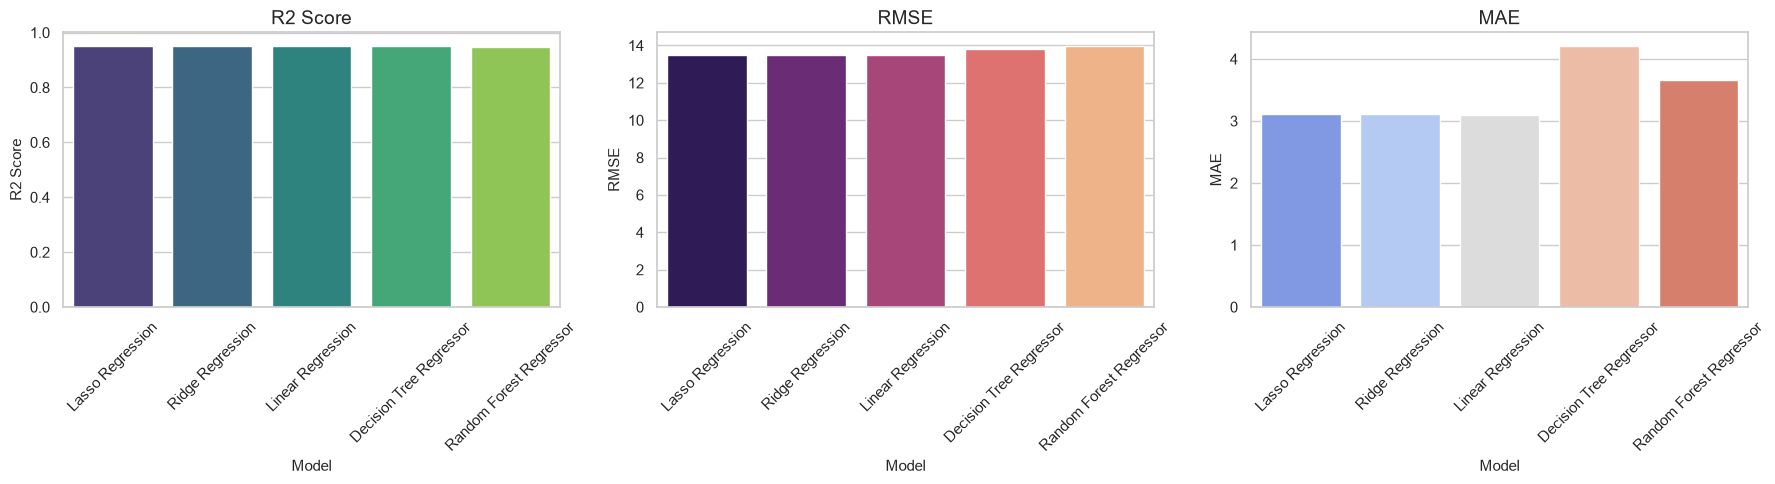

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=results_df, x="Model", y="R2 Score", ax=axes[0], palette="viridis")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("R2 Score")

sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[1], palette="magma")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("RMSE")

sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[2], palette="coolwarm")
axes[2].tick_params(axis="x", rotation=45)
axes[2].set_title("MAE")

plt.tight_layout()
plt.show()

## 11. Select the Best Model

We pick the model with the highest R2 score from the comparison table.

In [18]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_row = results_df.iloc[0]

print("Best model:", best_model_name)
print("R2 Score:", round(best_row["R2 Score"], 4))
print("RMSE:", round(best_row["RMSE"], 4))
print("MAE:", round(best_row["MAE"], 4))

Best model: Lasso Regression
R2 Score: 0.9526
RMSE: 13.4793
MAE: 3.1062


## 12. Feature Importance

We check which features matter most. For linear models, we use coefficients; for tree models, we use feature importance.

,Feature,Importance
14,device_TV,0.218110
17,country_DE,0.107640
9,category_Gaming,0.089396
11,category_Music,0.080111
15,device_Tablet,0.070904
20,country_US,0.068629
12,category_Tech,0.053267
18,country_IN,0.050935
19,country_UK,0.050256
13,device_Mobile,0.047384


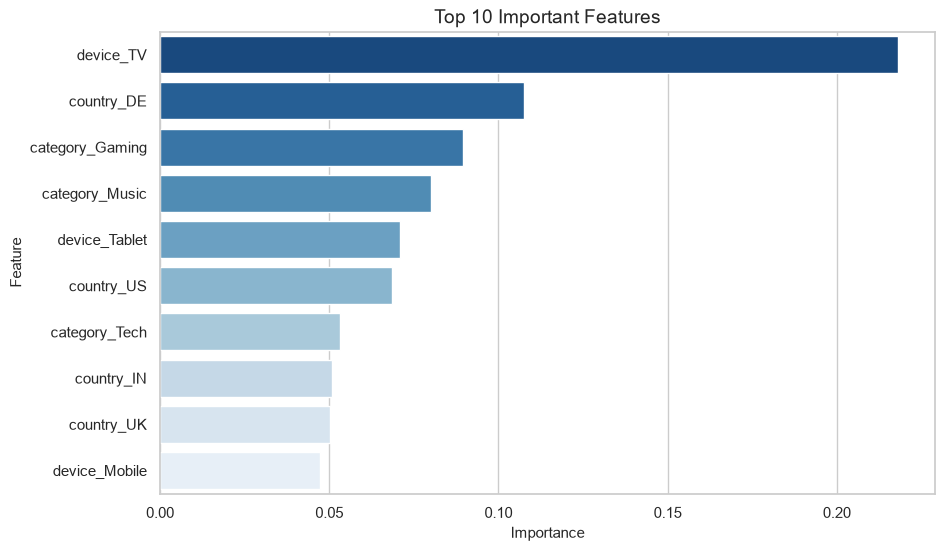

In [19]:
feature_names = X.columns

if hasattr(best_model, "feature_importances_"):
    importance_values = best_model.feature_importances_
else:
    importance_values = np.abs(best_model.coef_)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
}).sort_values("Importance", ascending=False)

display(importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature", palette="Blues_r")
plt.title("Top 10 Important Features")
plt.show()

## 13. Save the Trained Model

We save the best model and the training columns with Joblib so the Streamlit app can use the same data structure.

In [22]:
model_file = MODEL_FOLDER / "content_monetization_model.joblib"

artifact = {
    "model": best_model,
    "columns": X.columns.tolist()
}

joblib.dump(artifact, model_file)
print(f"Model saved to: {model_file}")

Model saved to: models\content_monetization_model.joblib


## 14. Conclusion

The notebook is complete. We cleaned the data, trained five models, selected the best one, and saved it for reuse.

In [21]:
print("Project Summary")
print("Best model:", best_model_name)
print("Test R2:", round(best_row["R2 Score"], 4))
print("Test RMSE:", round(best_row["RMSE"], 4))
print("Test MAE:", round(best_row["MAE"], 4))
print("The saved Joblib file can now be used in the Streamlit app.")

Project Summary
Best model: Lasso Regression
Test R2: 0.9526
Test RMSE: 13.4793
Test MAE: 3.1062
The saved Joblib file can now be used in the Streamlit app.
